In [ ]:
# All libs we need.
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Make some membership functions:
def trapezoidal_membership_function(domain, a, b, c, d):
    y = np.zeros_like(domain, dtype=float)

    # rising edge
    idx = (a < domain) & (domain < b)
    y[idx] = (domain[idx] - a) / (b - a)

    # top
    idx = (b <= domain) & (domain <= c)
    y[idx] = 1.0

    # falling edge
    idx = (c < domain) & (domain < d)
    y[idx] = (d - domain[idx]) / (d - c)

    return y


def gauss_mf(x, c, sigma):
    """
    Gaussian membership function
    """
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)


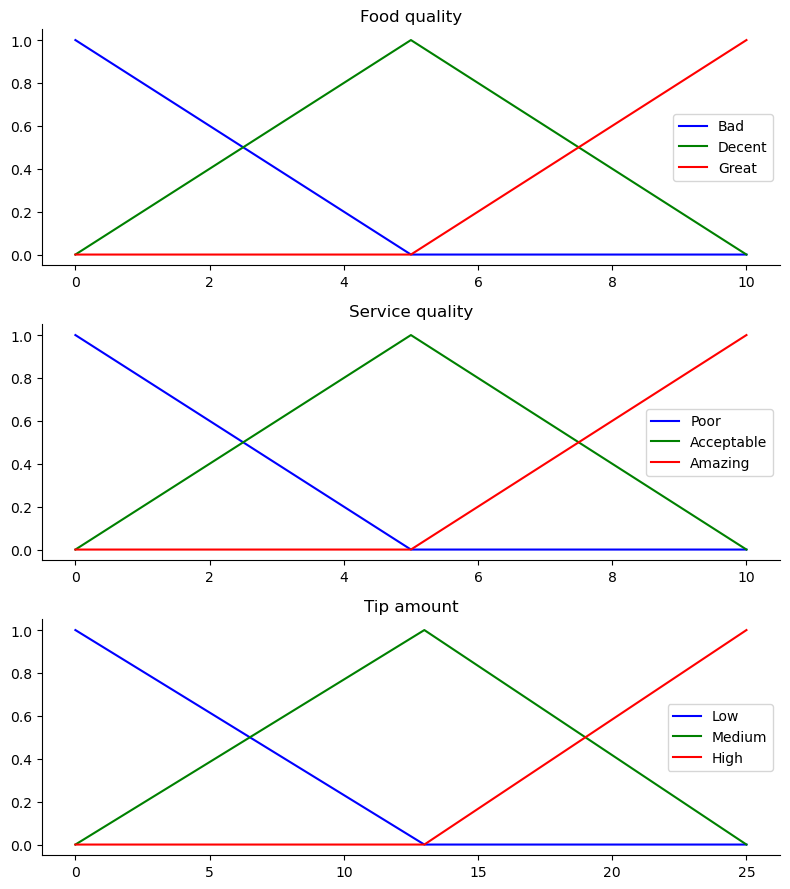

In [ ]:


#  quality and service on subjective ranges [0, 10]
#  tip has a range of [0, 25] in units of percentage points

domain_math_level = np.linspace(0, 10, 101) 
domain_work_load = np.linspace(0, 10, 101) 
domain_difficulty = np.linspace(0, 10, 101) 

# generate fuzzy membership functions on their corresponding domain.
# These functions are represent by the points and the corresponding values at those points. 
qual_lo_func = fuzz.trimf(domain_quality, [0, 0, 5])
qual_md_func = fuzz.trimf(domain_quality, [0, 5, 10])
qual_hi_func = fuzz.trimf(domain_quality, [5, 10, 10])
serv_lo_func = fuzz.trimf(domain_service, [0, 0, 5])
serv_md_func = fuzz.trimf(domain_service, [0, 5, 10])
serv_hi_func = fuzz.trimf(domain_service, [5, 10, 10])
tip_lo_func = fuzz.trimf(domain_tip, [0, 0, 13])
tip_md_func = fuzz.trimf(domain_tip, [0, 13, 25])
tip_hi_func = fuzz.trimf(domain_tip, [13, 25, 25])

# visualize these universes and membership functions
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, figsize=(8, 9)) # nrows=3 → creates 3 rows of plots (3 charts stacked vertically)

ax0.plot(domain_quality, qual_lo_func, 'b', linewidth=1.5, label='Bad')
ax0.plot(domain_quality, qual_md_func, 'g', linewidth=1.5, label='Decent')
ax0.plot(domain_quality, qual_hi_func, 'r', linewidth=1.5, label='Great')
ax0.set_title('Food quality')
ax0.legend()

ax1.plot(domain_service, serv_lo_func, 'b', linewidth=1.5, label='Poor')
ax1.plot(domain_service, serv_md_func, 'g', linewidth=1.5, label='Acceptable')
ax1.plot(domain_service, serv_hi_func, 'r', linewidth=1.5, label='Amazing')
ax1.set_title('Service quality')
ax1.legend()

ax2.plot(domain_tip, tip_lo_func, 'b', linewidth=1.5, label='Low')
ax2.plot(domain_tip, tip_md_func, 'g', linewidth=1.5, label='Medium')
ax2.plot(domain_tip, tip_hi_func, 'r', linewidth=1.5, label='High')
ax2.set_title('Tip amount')
ax2.legend()

# turn off top/right axes
for ax in (ax0, ax1, ax2):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()

plt.tight_layout()